In [42]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt


In [44]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\Customer_Feedback_and_Transaction_Data_Cleaned.csv")

In [46]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\Customer_Profile_For_Recommendation.csv")

In [48]:
df.columns

Index(['Customer_ID', 'total_transaction_amount', 'avg_transaction_amount',
       'income_level', 'income_level_encoded', 'bill_payment_count',
       'loan_payment_count', 'investment_count', 'purchase_count',
       'total_transaction_count', 'loan_payment_ratio', 'bill_payment_ratio',
       'investment_ratio', 'purchase_ratio', 'transaction_amount_std',
       'max_transaction_amount', 'min_transaction_amount',
       'high_value_txn_count', 'high_value_txn_ratio',
       'avg_satisfaction_score', 'engagement_count', 'satisfaction_std',
       'avg_ltr', 'loyalty_flag'],
      dtype='object')

In [50]:
features = [
    'total_transaction_amount',
    'total_transaction_count',
    'high_value_txn_count',
    'transaction_amount_std',
    'loan_payment_ratio',
    'investment_ratio',
    'purchase_ratio',
    'avg_satisfaction_score',
    'engagement_count',
    'avg_ltr'
]

X = df[features]

In [52]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

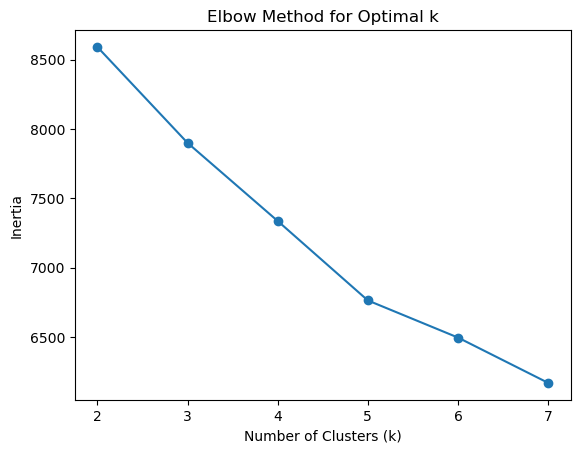

In [54]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 8), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

In [55]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [56]:
cluster_labels = {
    0: "Moderate Purchase-Oriented",
    1: "High-Value Power Users",
    2: "Investment-Focused Selective"
}

df['cluster_label'] = df['cluster'].map(cluster_labels)

In [57]:
cluster_summary = df.groupby('cluster')[features].mean()
cluster_summary

,total_transaction_amount,total_transaction_count,high_value_txn_count,transaction_amount_std,loan_payment_ratio,investment_ratio,purchase_ratio,avg_satisfaction_score,engagement_count,avg_ltr
cluster,,,,,,,,,,
0,7956.342188,3.509375,0.040625,1018.678801,0.237299,0.105104,0.367493,5.441435,4.765625,5.573501
1,18322.195274,6.907960,0.504975,1422.380320,0.297885,0.205072,0.233680,5.682990,4.800995,5.453535
2,9173.158273,3.956835,0.115108,1323.557268,0.183590,0.493131,0.133959,5.686706,5.446043,5.751056


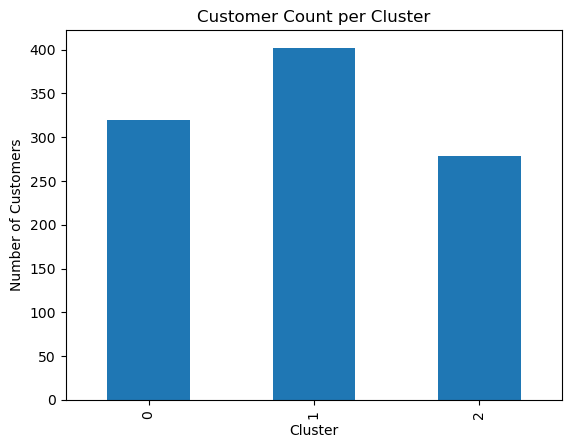

In [58]:
df['cluster'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Customer Count per Cluster")
plt.show()

Using the customer-level features engineered in Milestone 1, K-Means clustering was applied to segment FinMark customers into distinct groups based on financial behavior, transaction preferences, and engagement metrics. The resulting clusters reflect meaningful differences in spending capacity, transaction frequency, and customer engagement, consistent with the patterns identified during exploratory data analysis.